## **Are You Actually Gonna Work for Us Someday? A Data-Driven  Investigation into Penn Band’s Controversial March Madness Chant**

<img src="coverImage.png" width="800">

On March 19, 2026, University of Pennsylvania fell 105–70 to University of Illinois Urbana-Champaign in the opening round of the NCAA Tournament, ending what had otherwise been one of the most celebrated seasons in recent Penn basketball history. The Quakers had reached March Madness for the first time since 2018, reigniting excitement across campus and drawing national attention to a program that had long struggled to reestablish itself on the national stage. Within the Penn community, much of the postgame discussion initially centered around basketball itself: the absence of Penn’s leading scorer Ethan Roberts, concerns surrounding junior forward TJ Powers’ illness leading into the game, and the broader accomplishment of an Ivy League team returning to the tournament after years of inconsistency. But by the end of the night, the game itself had become secondary.

As the final minutes ticked down and Penn’s win became impossible, members of the Penn Band began chanting from the sidelines:

## ***“That’s alright, that’s okay, you’re gonna work for us someday.”***

The moment was captured on video and rapidly spread across social media platforms, transforming an otherwise ordinary March Madness blowout into a national debate about elitism, prestige, and the meaning of higher education in America. 

A repost of the clip by Yahoo Sports on X accumulated more than 4.2 million views within days: thousands of comments condemned the chant as arrogant, classist, and emblematic of Ivy League entitlement. Critics pointed out the irony of Penn students directing the chant toward a university widely recognized for its academic and professional strength. Even members of Penn’s own academic community publicly distanced themselves from the chant, with several professors and alumni expressing embarrassment online over the national perception it created.

<img src="commentResponses.png" width="800">

In response to the backlash, the Penn Band’s 2026 Executive Board released a formal statement on Instagram apologizing to students, faculty, and alumni at UIUC:

## ***“We’d like to specifically apologize to the University of Illinois’s players, faculty, students, and alumni– as representatives of a fellow collegiate institution, we recognize and respect the many contributions the University of Illinois has made to its community and society at large. We believe that individuals are not defined by institutional membership, and we recognize that the implications of our chant were misaligned with that belief.”***

The statement attempted to close the controversy, yet the discourse surrounding the chant revealed something deeper than a moment of poor sportsmanship. Beneath the outrage existed a quieter, but persistent, counterargument. Across Reddit threads, anonymous campus forums like Sidechat, and comment sections discussing the incident, some defended the chant. Supporters pointed to Penn’s status as an Ivy League institution, Wharton’s dominance in finance and consulting recruitment, and the long-standing cultural association between Ivy League degrees and professional power. Others argued that chants like these have existed for decades within Ivy League athletics and reflected a broader stereotype rather than a literal claim of superiority.

The controversy therefore raises a larger and more uncomfortable question:

*How much does institutional prestige actually translate into measurable post-graduate advantage?*

More specifically, does attending an Ivy League university like Penn meaningfully provide stronger long-term career outcomes than attending a highly-ranked public institution like University of Illinois Urbana-Champaign? And if so, in what ways? Is prestige reflected primarily through salary, elite employment pipelines, and social capital, or are factors like student happiness, debt burden, career satisfaction, and return on investment equally important indicators of success?

Rather than treating the chant as simply offensive or justified, our project uses it as a starting point for a broader investigation into the real-world value of elite higher education. By combining quantitative labor-market data with qualitative sentiment analysis, we aim to move beyond stereotypes and examine whether the assumptions embedded within the chant actually hold up under empirical scrutiny.


## Comparing Prestige and Perception: A Data-Driven Look at UPenn and UIUC Overall

When analyzing both schools, we looked into two aspects (quantitative and qualitative) to determine overall post-graduate advantage. On the quantitative side, it strictly involved analyzing financial measures like Median Earnings, ROI, Median Debt, Debt-to-Income Ratio, Demographics, Income Mobility, and Location. On the qualitative side, it included a sentiment analysis that numerically ranked online impressions of respective schools. 

After analyzing both sides of the data, it revealed that the conversation was much more nuanced than which school had a better outcome. Penn appeared to have a stronger financial return post graduation at the expense of a high pressure undergraduate experience, while UIUC appeared to have a more positive undergraduate experience with a lower long-term financial return. 


## The Numbers Behind the Degree: Earnings, Debt, ROI, and Economic Outcomes

Penn scored higher than UIUC across several financial aspects. Penn graduates reported higher median earnings at both the 6-year and 10-year mark. Penn graduates earned substantially more than UIUC graduates. The Penn median salary at 6 years was $85,900 and at 10 years $105,500. For UIUC, it was $51,000 at 6 years and $66,100 at 10 years. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
college_df = pd.read_csv('../data/raw/Overall_Data/overall.csv')

In [27]:
cleaned_df = college_df.rename(columns={
    "Median Earnings (6 yrs post-entry)": "earnings_6yr",
    "Median Earnings (10 yrs post-entry)": "earnings_10yr"
})

In [28]:
earnings_compare = cleaned_df[
    cleaned_df["School"].isin([
        "University of Pennsylvania",
        "University of Illinois Urbana-Champaign"
    ])
][["School", "earnings_6yr", "earnings_10yr"]]

earnings_compare

,School,earnings_6yr,earnings_10yr
4,University of Pennsylvania,$85900,$105500
9,University of Illinois Urbana-Champaign,$51000,$66100


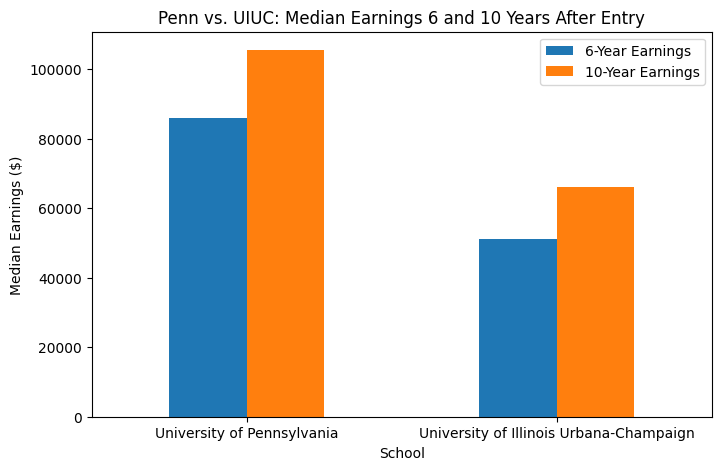

In [29]:
earnings_compare["earnings_6yr"] = earnings_compare["earnings_6yr"].str.replace("$", "").astype(int)
earnings_compare["earnings_10yr"] = earnings_compare["earnings_10yr"].str.replace("$", "").astype(int)

earnings_compare.set_index("School").plot(kind="bar", figsize=(8,5))

plt.title("Penn vs. UIUC: Median Earnings 6 and 10 Years After Entry")
plt.xlabel("School")
plt.ylabel("Median Earnings ($)")
plt.xticks(rotation=0)
plt.legend(["6-Year Earnings", "10-Year Earnings"])

plt.show()

Comparing each school’s average annual net cost with students’ median earnings after graduation, Penn had nearly double UIUC’s return on investment both at six years and 10 years. This went against the preconceived notion that public universities and state schools offer a better financial offer long-term. Penn’s higher post-graduation earnings offset the school’s higher tuition dramatically. Although Penn appears to be more expensive, the long-term benefits regarding income nearly double that of UIUC. 

In [36]:
compare = cleaned_df[
    cleaned_df["School"].isin([
        "University of Pennsylvania",
        "University of Illinois Urbana-Champaign"
    ])
][["School", "earnings_6yr", "earnings_10yr", "Median Debt at Graduation", "Avg Annual Cost (Net Price)"]]

compare["earnings_6yr"] = compare["earnings_6yr"].str.replace("$", "").astype(int)
compare["earnings_10yr"] = compare["earnings_10yr"].str.replace("$", "").astype(int)

compare["cost"] = compare["Avg Annual Cost (Net Price)"].str.replace("$", "").str.replace(",", "").astype(int) * 4

compare["roi_6yr"] = ((compare["earnings_6yr"] * 6 - compare["cost"]) / compare["cost"]) * 100
compare["roi_10yr"] = ((compare["earnings_10yr"] * 10 - compare["cost"]) / compare["cost"]) * 100

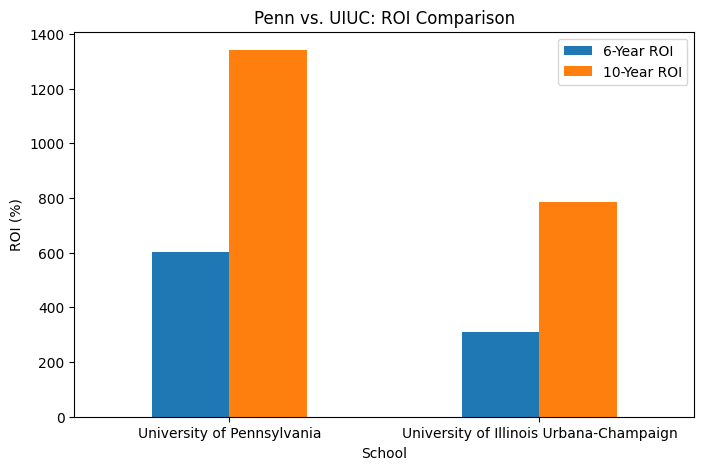

In [37]:
compare.set_index("School")[["roi_6yr", "roi_10yr"]].plot(kind="bar", figsize=(8,5))

plt.title("Penn vs. UIUC: ROI Comparison")
plt.ylabel("ROI (%)")
plt.xlabel("School")
plt.xticks(rotation=0)
plt.legend(["6-Year ROI", "10-Year ROI"])

plt.show()

However, ROI does not consider student-debt. Based on a compiled data set from government records, it revealed that Penn and UIUC students have similar debt levels at graduation. UIUC students have a median debt of $19,300 while Upenn students have a median debt of $18,300. UIUC has a slightly higher median debt, but with the difference only being about 5%. Although Ivy League schools are expected to leave students with considerable debt in comparison to a more practical options like state schools, this data conflicts with this expectation, indicating that UIUC students leave with slightly higher median debt. 

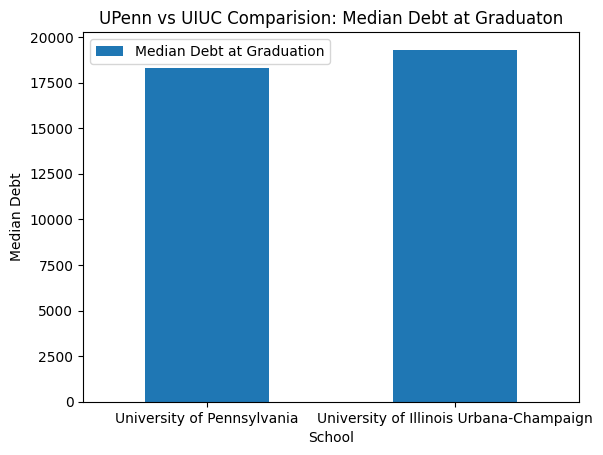

In [39]:
compare["Median Debt at Graduation"] = compare["Median Debt at Graduation"].str.replace("$", "").str.replace(",", "").astype(int)

compare.set_index("School")[["Median Debt at Graduation"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Median Debt at Graduaton")
plt.ylabel("Median Debt")
plt.xticks(rotation=0)
plt.show()

Even with similar debt levels, as Penn students earn more post-graduation, Penn’s debt-to-income ratio (debt compared to relative income post-graduation) is much lower. Penn’s debt-to-income ratio is at 17.3% compared to UIUC’s 29.2%. The data indicates that UIUC graduates carry a bigger financial burden post-graduation even with similar debt levels. It seems that Penn students are left in a more favorable financial position at graduation.

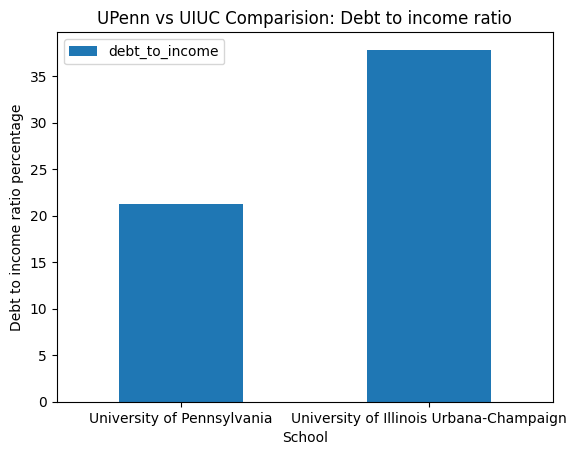

In [42]:
compare["debt_to_income"] = (compare["Median Debt at Graduation"] / compare["earnings_6yr"]) * 100

compare.set_index("School")[["debt_to_income"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Debt to income ratio")
plt.ylabel("Debt to income ratio percentage")
plt.xticks(rotation=0)
plt.show()

Based on this data alone, Penn seems to provide a much stronger financial outcome. However, the demographic and mobility data convolutes this claim. 

Although Penn students produce higher-earning graduates, the institution also enrolls an already wealthier student demographic. Based on the New York Times mobility index report card data gathered from tax records, Penn students come from wealthier households in comparison to UIUC students. The median family income of Penn students is $195,500 and for UIUC, $109,000. This is an important metric to consider, highlighting Penn students’ pre-existing advantages of coming from a higher income background. 

In [44]:
mobility_df = pd.read_csv('../data/raw/Overall_Data/upenn_mobility_clean.csv')

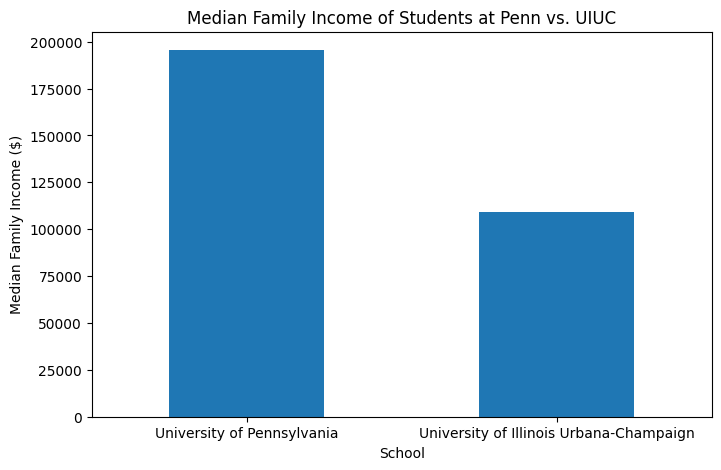

In [45]:
mobility_df.plot(
    x="school",
    y="median_family_income",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Median Family Income of Students at Penn vs. UIUC")
plt.xlabel("School")
plt.ylabel("Median Family Income ($)")
plt.xticks(rotation=0)
plt.show()

Penn also enrolls a higher group of students from the top 1%, while UIUC enrolls students largely from the bottom 20%. Penn graduates’ salaries can also be a reflection of pre-existing socioeconomic advantages that include things like networks, family wealth, and accessibility to elite career fields. 

UIUC seems to be stronger than Penn in the financial component of broader economic mobility. The data indicates that UIUC has a higher proportion of students moving up two or more income quintiles, suggesting that the school may serve as a stronger force for economic mobility across income groups instead of a concentrated group of high-income students. However, it is important to note that Penn does have a higher percentage of economic mobility in terms of moving the specific demographic of low-income students to the highest income threshold, but less of the overall student body. 


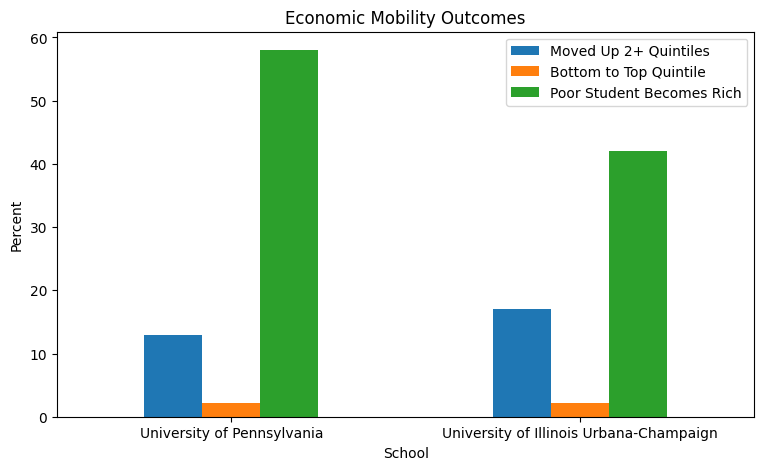

In [46]:
mobility_metrics = mobility_df.set_index("school")[[
    "pct_moved_up_2plus_quintiles",
    "pct_bottom_to_top_quintile",
    "pct_poor_student_becomes_rich"
]]

mobility_metrics.plot(kind="bar", figsize=(9,5))

plt.title("Economic Mobility Outcomes")
plt.xlabel("School")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.legend([
    "Moved Up 2+ Quintiles",
    "Bottom to Top Quintile",
    "Poor Student Becomes Rich"
])
plt.show()

Another interesting observation we came across was that the location of Penn graduates could either inflate or deflate their salaries’ value. Median income levels of Penn graduates are significantly higher than UIUC as analyzed above, but it is important to also consider the context of where Penn and UIUC graduates live post-graduation. 


Based on released Penn alumni data, it was posted that Penn alumni are concentrated in major cities like New York City, Philadelphia, and Boston. 


In [47]:
cities_df = pd.read_csv('../data/raw/Overall_Data/upenn_alumni_cities.csv')

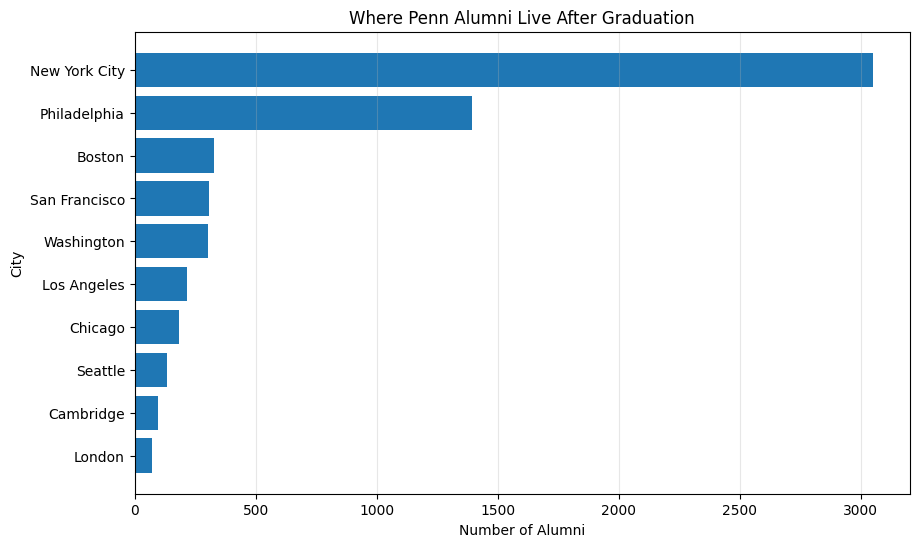

In [48]:
penn_df = cities_df.query('school == "University of Pennsylvania"')

penn_df = penn_df.sort_values("alumni_count")

plt.figure(figsize=(10,6))

plt.barh(
    penn_df["city"],
    penn_df["alumni_count"]
)

plt.xlabel("Number of Alumni")
plt.ylabel("City")

plt.title("Where Penn Alumni Live After Graduation")

plt.grid(axis="x", alpha=0.3)

plt.show()

Based on released UIUC alumni data, it was posted that UIUC alumni are majorly concentrated in the Illinois area with less variation in other cities and states like Penn. 

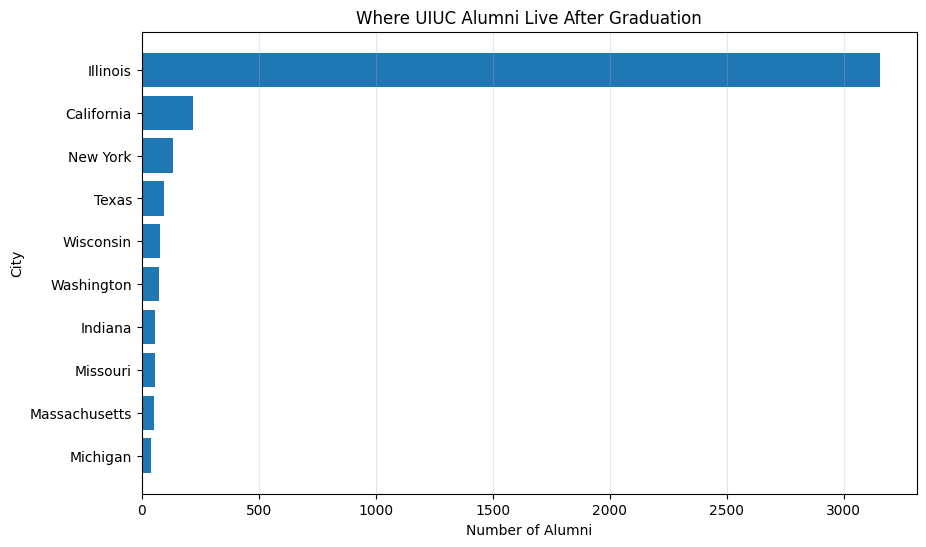

In [49]:
uiuc_df = cities_df.query('school == "University of Illinois Urbana-Champaign"')

uiuc_df = uiuc_df.sort_values("alumni_count")

plt.figure(figsize=(10,6))

plt.barh(
    uiuc_df["city"],
    uiuc_df["alumni_count"]
)

plt.xlabel("Number of Alumni")
plt.ylabel("City")

plt.title("Where UIUC Alumni Live After Graduation")

plt.grid(axis="x", alpha=0.3)

plt.show()

The data revealed that Penn grads are more concentrated in major cities that have higher costs of living than UIUC grads who live mostly in Chicago and the Midwestern area. The higher salaries of Penn students could be potentially deflated by the city which they live in, as the city involves more expenses. Penn graduates do have a salary advantage, but it is not a whole advantage considering where they live. 

As for the quantitative section, it revealed that the conversation is much more nuanced than which school has a better financial outcome. Although Penn seemed to provide stronger financial outcomes overall, UIUC was a stronger force for broader income mobility across socioeconomic groups. If success means a higher salary, Penn would lead UIUC with stronger ROI metrics and a lower debt-to-income ratio. However, a majority of Penn graduates are concentrated in major cities where the cost of living is high, which slightly negates this impact. If success means a broader economic mobility, UIUC would lead Penn as the school enrolls students from a much less wealthier background and appears to move a larger group of students upward across income quintiles. 


## Beyond the Statistics: Student Experiences of Happiness, Belonging, and Stress

After looking into each school’s financial aspects, it was also crucial to look into overall sentiments of respective schools. We analyzed emotional sentiment by identifying data across Reddit posts, student newspaper coverage, alumni surveys, Niche reviews, and other media sources. After providing Claude with 50 individual sources, it generated a sentiment analysis that was used to identify an overall sentiment score for each school in relation to categories like quality of life, student happiness, school belonging, and stress. 

After a sentiment analysis, it revealed that UIUC scored a positive sentiment score of 0.28 whereas Penn scored a negative sentiment score of -0.16. 


In [50]:
sentiment_df = pd.read_csv('../data/raw/Overall_Data/upenn_uiuc_sentiments.csv')

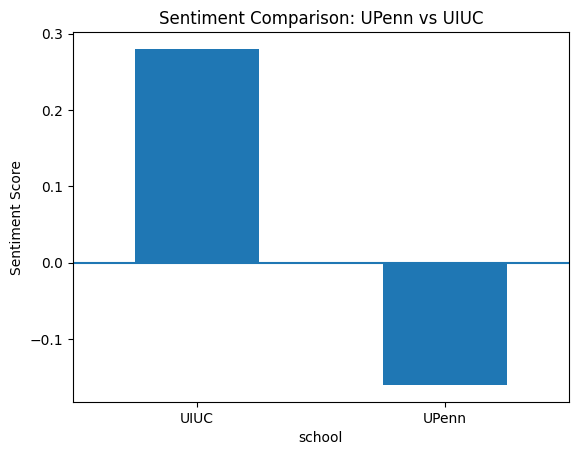

In [51]:
sentiment = sentiment_df.groupby("school")["manual_sentiment_score"].mean()

sentiment.plot(kind="bar")

plt.axhline(0) 
plt.title("Sentiment Comparison: UPenn vs UIUC")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=0)

plt.show()

Based on individual sentiment ratings, UIUC’s positive sentiment score was closely related to high scores in categories like community, school spirit, belonging, and overall happiness. UIUC’s value could be also derived from their overall stronger undergraduate experience. 


Penn’s sentiment analysis was much more complicated. Although the school scored well in individual post-grad and alumni-related categories, the current-student sentiment was much more negative, especially in categories of stress, competition, belonging, and mental health. It was interesting to note that Penn’s sentiment score tended to be much more positive after graduation rather than during enrollment, indicating that students reap benefits much later on. 

Based on both the quantitative and qualitative analysis of both schools, we came to the conclusion that Penn offers a stronger financial return, but appears to have a much weaker undergraduate experience based on stress and intensity. UIUC appears to offer a stronger undergraduate experience based on community and school spirit, but offers a lower long-term financial return. 